# 2 — Regresión lineal y cuadrados mínimos

📓 [Notebook de clase](../raw/2_regresion_lineal_cuadrados_minimos.ipynb) · ✏️ [Ejercicios](../exercises/2_regresion_lineal_cuadrados_minimos.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) como referencia principal

> **TL;DR**
>
> - La regresión lineal es lineal **en los parámetros $\beta$**, no en las
>   variables: $X_1^2$, $\log X_1$ o $X_1 X_2$ son predictores tan válidos como
>   $X_1$. Lo único que pedimos es que $f(X) = \beta_0 + \sum_j X_j \beta_j$.
> - Minimizar el error cuadrático ($RSS$) tiene **solución cerrada**:
>   $\hat\beta = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$, la
>   **ecuación normal**. Es un mínimo (no un máximo ni una silla) porque $RSS$
>   es convexa cuando $\mathbf{X}$ tiene rango columna completo.
> - Geométricamente, $\hat{\mathbf{y}}$ es la **proyección ortogonal** de
>   $\mathbf{y}$ sobre el subespacio que generan las columnas de $\mathbf{X}$.
>   El vector de residuos es perpendicular a ese subespacio: por eso la
>   ecuación normal se llama así.
> - Bajo supuestos extra (errores independientes, varianza constante $\sigma^2$,
>   normalidad) $\hat\beta$ es **insesgado**, tiene $Var(\hat\beta) = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$
>   y es normal. De ahí salen los $Z$-scores y el estadístico $F$ para decidir
>   qué coeficientes importan.
> - Cuando $N$ es gigante, calcular $\mathbf{X}^T\mathbf{X}$ es caro. El
>   **descenso por gradiente (estocástico)** encuentra el mismo $\hat\beta$ sin
>   necesidad de esa cuenta, a cambio de iterar y de elegir una tasa de
>   aprendizaje $\eta$.

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Regresión Lineal › Bibliografía: | 0 | Bibliografía citada en cada sección |
| Regresión Lineal: formulación | 1–3 | §1 |
| Entrenamiento | 4 | §2 |
| Entrenamiento - Cuadrados mínimos | 5–6 | §2 |
| Derivando matrices | 7 | §2 |
| Geometría de los resultados | 8–9 | §3 |
| Un poco de estadística | 10–13 | §4 |
| Un poco de estadística › Distribución | 14 | §5 |
| Un poco de estadística | 15–16 | §5 |
| Descenso por gradiente | 17–18 | §6 |

Nota sobre la celda 0: es la portada bibliográfica de la clase (Bishop cap. 3,
ESL cap. 3, y los tres papers de regularización). No abre tema propio, así que
no tiene una sección dedicada; las referencias puntuales de cada libro están
en el encabezado de cada sección de abajo.


In [1]:
# Setup — estilo de gráficos (ver referencias/estilo_graficos.md) + imports comunes
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})


---

## 1. El modelo lineal: qué asume y qué no

📓 celdas 1–3 · 📕 ESL §3.2 · 📘 Bishop §3.1

### La idea en criollo

Pensá en una balanza de las de antes, de platillos. De un lado ponés la
salida $Y$ que querés explicar. Del otro, vas apilando entradas $X_1, X_2,
\dots, X_p$, cada una con su propio peso $\beta_j$: cuánto mueve la balanza por
unidad que agregás de esa variable. El modelo lineal es la apuesta de que la
balanza queda equilibrada con una combinación de pesos **fija**, la misma para
cualquier combinación de entradas que le des.

> **Dónde se rompe la analogía.** En una balanza real los pesos son objetos
> físicos: no pueden ser negativos ni fraccionarios raros. Acá $\beta_j$ es
> cualquier número real, puede restar en vez de sumar, y no hay ninguna
> balanza que sostener: es una función que evaluás con una cuenta. La imagen
> sirve para la intuición de "suma ponderada de entradas", no para las
> restricciones del modelo.

### Formalizándolo

La clase escribe el modelo de dos formas, y las dos formas conviven en toda la
materia, así que conviene fijarlas desde acá.

**Forma expandida:**

$$f(X) = \beta_0 + \sum_{j=1}^{p} X_j \beta_j$$

$X^T = (X_1, X_2, \dots, X_p)$ (leelo "X transpuesta": el vector de las $p$
variables de entrada, escrito como fila) son las **variables de entrada**, y
$\beta = (\beta_0, \beta_1, \dots, \beta_p)$ (leelo "beta": el vector de
**coeficientes** o **parámetros** del modelo) son los números que hay que
estimar. $\beta_0$ es la **ordenada al origen** (*intercept*): el valor que
predice el modelo cuando todas las $X_j$ valen cero.

**Forma compacta:**

$$f(X) = X^T\beta$$

Para que esta forma funcione, hay que redefinir $X$: ahora es un vector de
tamaño $p+1$ que **arranca con un 1** y después trae los valores de las
variables, $X = (1, X_1, \dots, X_p)^T$. Ese 1 fijo es lo que hace que
$X^T\beta = 1 \cdot \beta_0 + X_1\beta_1 + \dots + X_p\beta_p$ reproduzca
exactamente la forma expandida. Es un truco de notación, no un supuesto nuevo:
metemos la ordenada al origen adentro del producto interno para no escribirla
aparte cada vez.

Ojo con la letra: de acá en más vas a ver $X$ (sin negrita) para el vector de
**una observación**, y más adelante $\mathbf{X}$ (con negrita) para la
**matriz** de $N$ observaciones apiladas, una por fila. Es el mismo símbolo
para dos objetos distintos, y la clase no lo aclara la primera vez que
aparece. Guardate la regla: minúscula o sin negrita = un vector; negrita
mayúscula = una matriz con una fila por observación.

**¿Qué estamos asumiendo con $f(X) = X^T\beta$?** (celda 2). La clase lo dice
en una línea y sigue de largo, pero vale la pena remarcarlo: **no** estamos
asumiendo que el mundo sea lineal. Estamos asumiendo que
$E(Y \mid X)$ —la **esperanza condicional** de $Y$ dado $X$, es decir el
promedio de $Y$ que esperarías si pudieras fijar $X$ y mirar infinitas
observaciones— **se aproxima bien** con una función lineal de $X$. Es una
afirmación sobre un promedio, no sobre cada observación individual: un $Y$
puntual puede estar lejísimos de la recta y el modelo seguir siendo razonable,
siempre que el promedio condicional sí se comporte así.

Esto conecta directo con la clase anterior. En teoría de la decisión vimos que,
bajo pérdida cuadrática, el predictor óptimo es exactamente
$f^*(X) = E(Y\mid X)$ (ESL §2.4). La regresión lineal no inventa un criterio
nuevo: **es una forma concreta y restringida de aproximar ese óptimo**,
apostando a que la función verdadera —sea cual sea— se deja aproximar bien por
un hiperplano.

**¿Qué son los $X$?** (celda 3). Acá está el punto que más confunde a quien
recién arranca: "lineal" es lineal **en los parámetros $\beta$**, no en las
variables de entrada. Eso abre la puerta a meter como $X_j$ prácticamente
cualquier cosa:

- variables continuas tal cual vienen,
- expansiones polinómicas ($X_1^2$, $X_1^3$, …) u otras transformaciones
  ($\log X_1$, $\sqrt{X_1}$),
- variables categóricas codificadas (por ejemplo con variables dummy),
- interacciones entre variables ($X_1 \cdot X_2$).

Todas esas son "regresión lineal" en el sentido que importa, porque
$f(X) = \beta_0 + \beta_1 X_1 + \beta_2 X_1^2$ sigue siendo lineal en
$(\beta_0, \beta_1, \beta_2)$, aunque como función de $X_1$ dibuje una parábola.

### ¿Por qué nos importa?

Porque esta flexibilidad es la que hace que la regresión lineal aguante mucho
más de lo que el nombre sugiere. Cuando en unas clases más veas selección de
variables, regularización (Ridge, Lasso) o incluso ciertas redes con una capa,
vas a estar parado sobre esta misma formulación: un modelo lineal en $\beta$,
con $X$ construido con la libertad que acabamos de ver.


In [2]:
# "Lineal en los parámetros" con una entrada no lineal: X1 y X1^2 conviven.
x1 = np.array([1.0, 2.0, 3.0, 4.0])
X_ej1 = np.column_stack([np.ones_like(x1), x1, x1**2])  # columna de 1s + X1 + X1^2
beta_ej1 = np.array([1.0, 0.5, -0.2])                    # beta0, beta1, beta2

f = X_ej1 @ beta_ej1  # sigue siendo X^T beta, sumatoria fila a fila
print("f(x1) =", f.round(3))  # la parábola evaluada en cada x1


f(x1) = [ 1.3  1.2  0.7 -0.2]


El modelo predice una **parábola** en función de $x_1$ (la salida de arriba
lo confirma: no crece linealmente), pero seguís pudiendo escribirlo como
$X^T\beta$ y resolverlo con las mismas herramientas que un modelo lineal "de
toda la vida".

### ⚠️ Confusión típica

Leer "regresión *lineal*" y esperar que el gráfico de $Y$ contra $X$ sea
siempre una recta. No: la restricción es sobre $\beta$, no sobre la forma de
la curva que termina dibujando el modelo en función de las variables
originales.


---

## 2. Cuadrados mínimos: planteando y resolviendo la minimización

📓 celdas 4–7 · 📕 ESL §3.2 · 📘 Bishop §3.1.1

### La idea en criollo

Tenés $N$ puntos de datos y una familia de rectas (o planos, o hiperplanos)
candidatas, una por cada valor posible de $\beta$. Para cada candidata podés
medir cuánto "yerra": la distancia vertical entre cada dato real y lo que la
recta predice para ese mismo $x$. Cuadrados mínimos dice: sumá esos errores
**al cuadrado**, y quedate con la recta que hace esa suma lo más chica
posible.

> **Dónde se rompe la analogía.** "Elevar al cuadrado" no es un detalle
> cosmético. Convierte al problema en una cuadrática pura en $\beta$, que es
> justo lo que le va a permitir a esta sección resolverlo con álgebra en vez
> de con prueba y error. Si en cambio sumaras los errores **absolutos** (como
> pregunta el Ejercicio 1), seguís teniendo un problema de minimización
> razonable, pero deja de tener esta solución cerrada tan cómoda.

### Formalizándolo

**Planteo (celda 4).** Dado un conjunto de entrenamiento
$\{(x_1, y_1), \dots, (x_N, y_N)\}$, donde cada $x_i = (x_{i1}, \dots, x_{ip})$
es el vector de atributos de la observación $i$-ésima, "ajustar bien" se
traduce en minimizar una función de costo. La más común es la **suma de los
residuos al cuadrado**:

$$RSS = \sum_{i=1}^{N} (y_i - f(x_i))^2$$

$RSS$ es sigla de *residual sum of squares* (suma de cuadrados de los
residuos). Un **residuo** es, para cada observación, lo que le sobra o le
falta al modelo: $y_i - f(x_i)$.

**Forma matricial (celda 5).** Apilando las $N$ observaciones, $\mathbf{y}$ es
el vector columna de las $N$ respuestas y $\mathbf{X}$ es la matriz
$N \times (p+1)$ que tiene a cada $x_i$ (con el 1 del intercepto adelante)
como fila. La suma de cuadrados se reescribe como una norma:

$$RSS(\beta) = \|\mathbf{y} - \mathbf{X}\beta\|^2 = (\mathbf{y} - \mathbf{X}\beta)^T(\mathbf{y} - \mathbf{X}\beta)$$

(Acordate: $\|v\|^2 = v^T v$ para cualquier vector $v$ — la norma al cuadrado
es el vector multiplicado por sí mismo. Nada más que eso.) Escribirla como
norma hace explícito que $RSS$ depende de $\beta$, y prepara el terreno para
derivar.

**La derivación completa, paso a paso (celda 7).** La clase da directamente
las dos derivadas en la celda 5 y recién las justifica en la celda 7 ("Derivando
matrices"); acá las juntamos en el orden que tiene sentido para seguirlas.
Arrancamos abriendo el binomio, exactamente como abrirías $(a-b)(a-b)$:

$$(\mathbf{y} - \mathbf{X}\beta)^T(\mathbf{y} - \mathbf{X}\beta) = (\mathbf{y}^T - \beta^T\mathbf{X}^T)(\mathbf{y} - \mathbf{X}\beta) = \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\beta - \beta^T\mathbf{X}^T\mathbf{y} + \beta^T\mathbf{X}^T\mathbf{X}\beta$$

Los dos términos del medio se ven distintos, pero son el **mismo número**.
Fijate en las dimensiones: $\mathbf{y}^T$ es $1 \times N$, $\mathbf{X}$ es
$N \times (p{+}1)$, $\beta$ es $(p{+}1) \times 1$. El producto completo da
$1\times 1$: un escalar. Y todo escalar es igual a su propia transpuesta, así
que $\mathbf{y}^T\mathbf{X}\beta = (\mathbf{y}^T\mathbf{X}\beta)^T = \beta^T\mathbf{X}^T\mathbf{y}$.
Sumando esos dos términos iguales:

$$RSS(\beta) = \mathbf{y}^T\mathbf{y} - 2\,\mathbf{y}^T\mathbf{X}\beta + \beta^T\mathbf{X}^T\mathbf{X}\beta$$

Esto es una **cuadrática en $\beta$**: un término constante, uno lineal y uno
cuadrático — la misma pinta que $c - 2b\beta + a\beta^2$, pero con vectores y
matrices en el lugar de los números.

Ahora derivamos respecto de $\beta$, que es un **vector columna**: por eso la
derivada tiene que dar otro vector columna, con tantas componentes como
$\beta$. Usamos dos propiedades de cálculo matricial:

- $\dfrac{\partial(a^T\beta)}{\partial \beta} = a$ si $a$ no depende de
  $\beta$ (análogo escalar: $\frac{d}{dx}(bx) = b$).
- $\dfrac{\partial(\beta^T A \beta)}{\partial \beta} = 2A\beta$ cuando $A$ es
  simétrica (análogo escalar: $\frac{d}{dx}(ax^2) = 2ax$).

$\mathbf{X}^T\mathbf{X}$ **es** simétrica: $(\mathbf{X}^T\mathbf{X})^T = \mathbf{X}^T(\mathbf{X}^T)^T = \mathbf{X}^T\mathbf{X}$.
Derivando término a término:

$$\frac{\partial}{\partial \beta}(\mathbf{y}^T\mathbf{y}) = 0, \qquad \frac{\partial}{\partial \beta}(-2\mathbf{y}^T\mathbf{X}\beta) = -2\mathbf{X}^T\mathbf{y}, \qquad \frac{\partial}{\partial \beta}(\beta^T\mathbf{X}^T\mathbf{X}\beta) = 2\mathbf{X}^T\mathbf{X}\beta$$

y sumando los tres:

$$\frac{\partial RSS}{\partial \beta} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\beta = -2\mathbf{X}^T(\mathbf{y} - \mathbf{X}\beta)$$

que es exactamente la primera derivada que la clase escribe de entrada en la
celda 5. La segunda derivada sale de derivar otra vez ese resultado respecto
de $\beta$ (la clase la anota con un asterisco aclarando que "deja de lado un
$\beta^T$ para simplificar la notación": es la forma abreviada habitual de
escribir la matriz Hessiana sin repetir el $\beta^T$ que en rigor multiplica
por delante):

$$\frac{\partial^2 RSS}{\partial \beta^2} = 2\mathbf{X}^T\mathbf{X}$$

**La ecuación normal (celda 6).** Un punto crítico de $RSS$ se obtiene
igualando la primera derivada a cero:

$$\mathbf{X}^T(\mathbf{y} - \mathbf{X}\beta) = 0 \quad\Longleftrightarrow\quad \mathbf{X}^T\mathbf{X}\hat\beta = \mathbf{X}^T\mathbf{y}$$

Esta es la **ecuación normal**. Si $\mathbf{X}$ tiene **rango columna
completo** (sus $p+1$ columnas son linealmente independientes), $\mathbf{X}^T\mathbf{X}$
es invertible y se puede despejar:

$$\hat\beta = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

**Un paso que la clase da por hecho y conviene no saltear**: que la derivada
primera se anule prueba que $\hat\beta$ es un **punto crítico**, no que sea un
mínimo. Podría ser un máximo o un punto silla. Lo que decide es la segunda
derivada, $2\mathbf{X}^T\mathbf{X}$. Para cualquier vector $v$,
$v^T(\mathbf{X}^T\mathbf{X})v = \|\mathbf{X}v\|^2 \geq 0$: la matriz es
**semidefinida positiva siempre**, sin ninguna condición extra. Es **definida**
positiva —estrictamente mayor que cero para $v \neq 0$— si y solo si
$\mathbf{X}v \neq 0$ para todo $v\neq 0$, que es exactamente la condición de
rango columna completo. Con eso, $RSS$ es **estrictamente convexa** y el punto
crítico que encontramos es el **mínimo global**. Recién ahí la cuenta está
cerrada: es lo que la celda 6 resume en una frase ("$\mathbf{X}^TX$ es
definida positiva, lo que implica que la función de costo es convexa").

Con $\hat\beta$ ya resuelto, las predicciones se obtienen evaluando el modelo
en los mismos datos de entrenamiento:

$$\hat{\mathbf{y}} = \mathbf{X}\hat\beta = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

### ¿Por qué nos importa?

Porque cuadrados mínimos es de las poquísimas veces en toda la materia en que
vas a tener una **solución cerrada**. No hay que iterar, no hay tasa de
aprendizaje que ajustar, no hay mínimos locales de los que preocuparse:
escribís la fórmula y listo. Como dice la propia clase, "desde un punto de
vista operativo, ya está" — casi no hicieron falta hipótesis sobre los datos,
más allá de que $\mathbf{X}$ tenga rango completo.

Ese lujo se paga: te lo da la combinación exacta de un modelo lineal en
$\beta$ con una pérdida cuadrática. Cambiá cualquiera de las dos piezas
—pérdida absoluta, regresión logística, una red neuronal— y la solución
cerrada desaparece. Por eso el resto de la materia optimiza numéricamente
(justo lo que vas a ver en la §6 de esta misma clase). Guardate esta cuenta
como el caso de referencia contra el que comparás todo lo demás.


In [3]:
# prostate.data: 8 predictores (lcavol ... pgg45), respuesta lpsa, columna 'train'.
# Este X y este y son los que vamos a reusar en el resto de la notebook.
df = pd.read_csv(Path("../../datasets/prostate.data"), sep="\t").drop(columns="Unnamed: 0", errors="ignore")
pred = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]

X = np.column_stack([np.ones(len(df)), df[pred].to_numpy()])  # columna de 1s + predictores
y = df["lpsa"].to_numpy()

XtX, Xty = X.T @ X, X.T @ y

beta_mal = np.linalg.inv(XtX) @ Xty                  # traduce la fórmula, pero no se hace así
beta_ok = np.linalg.solve(XtX, Xty)                  # resuelve el sistema lineal sin invertir nada
beta_mejor, *_ = np.linalg.lstsq(X, y, rcond=None)   # ni siquiera arma X^T X

print("beta (inv):   ", beta_mal.round(4))
print("beta (solve): ", beta_ok.round(4))
print("beta (lstsq): ", beta_mejor.round(4))
print("coinciden inv/solve/lstsq:", np.allclose(beta_mal, beta_ok) and np.allclose(beta_ok, beta_mejor))


beta (inv):    [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
beta (solve):  [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
beta (lstsq):  [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
coinciden inv/solve/lstsq: True


Los tres dan el mismo resultado (la salida de arriba lo confirma: con
`prostate.data`, que está razonablemente bien condicionado, `cond(X)` no es
tan grande como para que `inv` se note). Cuando las columnas de $\mathbf{X}$
están muy correlacionadas, `inv` amplifica el error numérico: al formar
$\mathbf{X}^T\mathbf{X}$, el número de condición de la matriz se **eleva al
cuadrado**. `lstsq` trabaja directo sobre $\mathbf{X}$ (vía descomposición QR
o SVD) y esquiva ese problema — es, de hecho, lo que usa `sklearn` por dentro
(lo vas a comprobar vos mismo en el Ejercicio 5).

#### 🏭 Así se hace en la industria

En la práctica nadie arma la ecuación normal a mano: se usa la librería, que
además agrega el intercepto sola.


In [4]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression().fit(X[:, 1:], y)  # sklearn agrega el intercepto solo
beta_sklearn = np.concatenate([[modelo.intercept_], modelo.coef_])

print("beta (sklearn):", beta_sklearn.round(4))
print("coincide con lstsq:", np.allclose(beta_sklearn, beta_mejor))


beta (sklearn): [ 0.1816  0.5643  0.622  -0.0212  0.0967  0.7617 -0.1061  0.0492  0.0045]
coincide con lstsq: True


Mismo resultado que `lstsq`, con la API que se usa en la práctica: no hay
ecuación normal escrita en ningún lado del código de quien la usa, solo
`.fit(X, y)`.

### ⚠️ Confusión típica

Ver el $^{-1}$ en $\hat\beta = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$
y pensar que el algoritmo consiste en invertir una matriz. La fórmula es
**notación**; en la práctica se **resuelve un sistema lineal** (`solve` o
`lstsq`), nunca se invierte nada explícitamente. Si te preguntan cómo se
calcula $\hat\beta$ en la práctica, "invirtiendo $\mathbf{X}^T\mathbf{X}$" es
la respuesta que no querés dar.

Segunda trampa, más conceptual: $(\mathbf{X}^T\mathbf{X})^{-1}$ existe **solo
si** $\mathbf{X}$ tiene rango columna completo. Eso se rompe si hay más
variables que observaciones ($p+1 > N$) o si una columna es combinación
lineal de otras (clásico: codificar una variable categórica con una dummy por
categoría **y además** dejar el intercepto). Ahí no hay un único $\hat\beta$:
hay infinitos, todos con el mismo $RSS$ mínimo — es justo el tema de la
próxima sección.


---

## 3. Geometría: proyección ortogonal y la matriz *hat*

📓 celdas 8–9 · 📕 ESL §3.2 (Fig. 3.2) · 📘 Bishop §3.1.2

### La idea en criollo

Imaginate tu casa en medio del campo y una ruta recta que pasa cerca. Querés
el punto de la ruta más próximo a tu casa. ¿Qué hacés? Trazás la
**perpendicular** a la ruta. Cualquier otro punto de la ruta queda más lejos,
y eso lo sabés sin recorrer la ruta punto por punto: es geometría pura.

Cuadrados mínimos es exactamente eso. Tu "casa" es el vector de respuestas
observadas $\mathbf{y}$. La "ruta" es el conjunto de **todas las predicciones
que tu modelo puede generar** al barrer todos los $\beta$ posibles. Buscás el
punto de ese conjunto más cercano a $\mathbf{y}$, y ese punto es $\hat{\mathbf{y}}$.

> **Dónde se rompe la analogía.** La ruta del ejemplo es una recta en el
> plano: dos dimensiones, fácil de dibujar. Acá $\mathbf{y}$ vive en
> $\mathbb{R}^N$ —una dimensión **por observación**, no por variable— y la
> "ruta" es un subespacio de hasta $p+1$ dimensiones dentro de ese espacio
> gigante. No hay forma de dibujarlo si $N > 3$, pero la cuenta de la
> perpendicular es idéntica. Y ojo: la distancia que minimizamos es entre
> **vectores de $N$ componentes**, no entre puntos del típico gráfico de $x$
> contra $y$ que tenés en la cabeza cuando pensás "una recta que ajusta
> puntos".

### Formalizándolo

Las columnas de $\mathbf{X}$ (una por cada variable, más la columna de 1s del
intercepto) generan un subespacio de $\mathbb{R}^N$: el conjunto de todos los
vectores que se pueden escribir como $\mathbf{X}\beta$ para algún $\beta$. Ese
es el conjunto de "todas las predicciones alcanzables" de la analogía.

De la ecuación normal, $\mathbf{X}^T(\mathbf{y} - \mathbf{X}\hat\beta) = 0$, se
deduce algo geométrico fuerte: el vector de residuos
$\mathbf{y} - \hat{\mathbf{y}}$ es **ortogonal** a cada columna de
$\mathbf{X}$ (porque $\mathbf{X}^T$ aplicado a ese vector da cero), y por lo
tanto ortogonal a **todo** el subespacio que esas columnas generan. Un vector
ortogonal al subespacio completo, sumado a un vector dentro del subespacio,
da la descomposición geométrica de una proyección: $\hat{\mathbf{y}}$ es la
**proyección ortogonal** de $\mathbf{y}$ sobre el subespacio de columnas de
$\mathbf{X}$, y $\mathbf{y} - \hat{\mathbf{y}}$ es la parte de $\mathbf{y}$
que ese subespacio no puede explicar.

La matriz que hace esa proyección tiene nombre propio:

$$\hat{\mathbf{y}} = \mathbf{X}\hat\beta = \underbrace{\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T}_{\mathbf{H}}\,\mathbf{y}$$

$\mathbf{H}$ se llama **matriz de proyección** o **matriz *hat*** (te "pone
el sombrero" a $\mathbf{y}$: la transforma en $\hat{\mathbf{y}}$). Vale la
pena notar dos propiedades que se derivan directo de la fórmula, aunque la
clase no las escriba: $\mathbf{H}$ es **simétrica** ($\mathbf{H}^T = \mathbf{H}$,
se verifica reemplazando en la fórmula) e **idempotente**
($\mathbf{H}\mathbf{H} = \mathbf{H}$: proyectar dos veces es lo mismo que
proyectar una vez, que es justamente lo que se espera de una proyección).


#### 🖼️ La figura de la clase

![Proyección ortogonal de y sobre el espacio columna de X, con el vector de residuos perpendicular al plano](../../figuras/Geometría cuadrados mínimos.png)

Es el dibujo canónico de este resultado —el mismo que aparece como **ESL Fig.
3.2**—: un plano (el subespacio de dos dimensiones que generan dos columnas de
$\mathbf{X}$, dibujado como una hoja dentro de un espacio de tres ejes) con el
vector $\mathbf{y}$ señalado **fuera** de ese plano, una flecha perpendicular
bajando desde la punta de $\mathbf{y}$ hasta el plano, y el punto donde esa
perpendicular toca el plano marcado como $\hat{\mathbf{y}}$. El segmento que
conecta $\mathbf{y}$ con $\hat{\mathbf{y}}$ es el vector de residuos, dibujado
en ángulo recto respecto del plano. Es la traducción literal a un dibujo de la
ecuación $\mathbf{X}^T(\mathbf{y}-\hat{\mathbf{y}}) = 0$.

**¿Cuál es la dimensión de ese subespacio?** (pregunta abierta de la celda 9,
respondida en la sección de cierre de más abajo).

**¿Cuándo hay problemas?** Si las columnas de $\mathbf{X}$ **no** son
linealmente independientes —no tiene rango completo— entonces
$\mathbf{X}^T\mathbf{X}$ no es invertible, y no hay una única forma de
escribir $\hat\beta$. Pero la geometría no se rompe: $\hat{\mathbf{y}}$ sigue
siendo la proyección ortogonal de $\mathbf{y}$ sobre el subespacio (el
subespacio en sí no cambia, solo tiene menos de $p+1$ dimensiones). Lo que se
pierde es la unicidad de $\beta$: hay infinitos vectores $\beta$ que producen
el mismo $\hat{\mathbf{y}}$, porque hay más de una combinación de columnas
—dependientes entre sí— que llega al mismo punto del subespacio.


In [5]:
# H sobre los datos reales de prostate.data (N=97, p+1=9): verificamos las dos
# propiedades de la matriz hat sin necesidad de dibujar nada en R^97.
H = X @ np.linalg.inv(X.T @ X) @ X.T

simetrica = np.allclose(H, H.T)
idempotente = np.allclose(H @ H, H)
traza = np.trace(H)

print("H simétrica:", simetrica)
print("H idempotente (H@H == H):", idempotente)
print(f"traza(H) = {traza:.4f}  (esperado: p+1 = {X.shape[1]})")


H simétrica: True
H idempotente (H@H == H): True
traza(H) = 9.0000  (esperado: p+1 = 9)


La traza de $\mathbf{H}$ da exactamente $p+1$: es otra forma de ver la
dimensión del subespacio de proyección (la traza de una proyección ortogonal
es igual a la dimensión del subespacio sobre el que proyecta).

### ¿Por qué nos importa?

Porque esta imagen geométrica es la que después explica **todo** lo raro que
vas a ver sobre regresión lineal: por qué agregar una variable nunca puede
aumentar el $RSS$ (agrandar el subespacio nunca aleja la proyección), por qué
dos predictores muy correlacionados generan coeficientes inestables (el
subespacio casi no cambia de forma al sacar o meter esa columna, entonces hay
muchas combinaciones $\beta$ casi igual de buenas), y por qué la
ortogonalización de predictores (ESL §3.2.3, la próxima clase probablemente la
toque) simplifica tanto las cuentas.

### ⚠️ Confusión típica

Pensar la proyección como algo que pasa "en el gráfico de $x$ vs $y$" que uno
dibuja a mano. La proyección ocurre en $\mathbb{R}^N$, el espacio de las
observaciones, no en el espacio de las variables. Son dos geometrías
distintas que se confunden fácil porque las dos "se ven como una recta que
pasa cerca de unos puntos".

### ❓ La pregunta que quedó abierta

En la celda 9 la clase pregunta *"¿cuál es su dimensión?"* (la del subespacio
generado por las columnas de $\mathbf{X}$) y sigue de largo sin responder.
La respuesta es el **rango** de $\mathbf{X}$. Si $\mathbf{X}$ tiene rango
columna completo, la dimensión es $p+1$: una por cada predictor más el
intercepto — y es exactamente lo que la celda de código de arriba acaba de
confirmar con `traza(H)` sobre datos reales. Si dos o más columnas son
linealmente dependientes, la dimensión es menor que $p+1$ — y ese es
exactamente el caso en el que $(\mathbf{X}^T\mathbf{X})^{-1}$ deja de existir,
que es la otra pregunta que la clase se hace unas líneas más abajo ("¿cuándo
hay problemas?"). Las dos preguntas son, en el fondo, la misma pregunta.


---

## 4. Esperanza del estimador: por qué $\hat\beta$ es insesgado

📓 celdas 10–13 (esperanza) · 📕 ESL §3.2 · 📘 Bishop §3.1.1

### La idea en criollo

Pensá en una balanza de precisión que usás muchas veces para pesar el mismo
objeto. Cada pesada te da un número levemente distinto —ruido del instrumento,
corrientes de aire, lo que sea—, pero si promediás miles de pesadas, ese
promedio converge al peso real. Un estimador **insesgado** es eso: no pesa
"para cualquier lado" en promedio, aunque cada pesada individual (cada
muestra de datos que te toque) se equivoque.

> **Dónde se rompe la analogía.** La balanza pesa el mismo objeto fijo cada
> vez. Acá, lo que varía de "pesada en pesada" no es $\beta$ (que es fijo y
> desconocido) sino la muestra de datos que te toca: otro conjunto de $N$
> observaciones te da otro $\hat\beta$, porque el ruido $\epsilon$ es distinto
> cada vez. La "balanza" en este caso es todo el procedimiento de ajuste, no
> un instrumento físico.

### Formalizándolo

Dado un estimador, las tres preguntas de siempre son: ¿tiene sesgo?, ¿cuánto
varía?, ¿qué distribución sigue? Para responderlas hace falta agregar
supuestos sobre cómo se generaron los datos —cosa que hasta acá no habíamos
necesitado—. La clase (celda 11) los introduce de manera incremental:

1. **El modelo lineal es correcto**: $Y = E(Y\mid X_1,\dots,X_p) + \epsilon = \beta_0 + \sum_j X_j\beta_j + \epsilon$.
   Es decir, existe un $\beta$ "verdadero" tal que la relación entre $X$ e $Y$
   es exactamente lineal más un término de error.
2. Las observaciones $y_i$ son **independientes** entre sí, con **varianza
   constante** $\sigma^2$ (a esto se le llama *homocedasticidad*).
3. Los $x_i$ son **fijos**, no aleatorios (el análisis condiciona en el
   diseño observado).
4. Los errores siguen una **distribución normal**: $\epsilon \sim N(0, \sigma^2)$.

Es común escribir el supuesto 2 en forma matricial como $Var(\epsilon) = \sigma^2 I$,
con $I$ la matriz identidad: dice, al mismo tiempo, que todos los errores
tienen la misma varianza $\sigma^2$ (los términos de la diagonal) y que son
no correlacionados entre sí (los términos fuera de la diagonal son cero,
porque son independientes).

**La cuenta de la esperanza (celda 12).** Partimos de $\hat\beta = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$
y reemplazamos $\mathbf{y}$ por el modelo verdadero del supuesto 1,
$\mathbf{y} = \mathbf{X}\beta + \epsilon$:

$$\hat\beta = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{X}\beta + \epsilon) = \underbrace{(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}}_{=\,I}\beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\epsilon = \beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\epsilon$$

(El paso intermedio usa que $(\mathbf{X}^T\mathbf{X})^{-1}(\mathbf{X}^T\mathbf{X}) = I$,
por definición de matriz inversa.) Esta expresión —$\hat\beta$ escrito como
el $\beta$ verdadero más un término que depende solo del ruido— es la que se
va a reutilizar en toda esta sección y en la próxima.

Tomando esperanza en ambos lados, y usando que $\mathbf{X}$ es fija (supuesto
3, así que $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ sale de la esperanza
como constante):

$$E(\hat\beta) = \beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\,E(\epsilon)$$

y como $E(\epsilon) = 0$ (parte del supuesto 4, aunque en rigor alcanza con
que $E(\epsilon)=0$, no hace falta normalidad para esto), el segundo término
se anula:

$$E(\hat\beta) = \beta$$

$\hat\beta$ es un estimador **insesgado**: no hay ningún sesgo sistemático
que lo aleje del $\beta$ verdadero, sin importar qué muestra particular te
haya tocado.

### ¿Por qué nos importa?

Porque la insesgadez es la base para todo lo que viene después: intervalos de
confianza, tests de hipótesis sobre coeficientes individuales, el estadístico
$F$. Ninguna de esas herramientas tiene sentido si el estimador está sesgado
de entrada — estarías construyendo un intervalo de confianza alrededor de un
número que sistemáticamente no es el que buscás. Vale la pena adelantar,
aunque esta clase no lo desarrolle, que **Ridge y Lasso (ESL §3.4) rompen
esta propiedad a propósito**: aceptan algo de sesgo a cambio de reducir la
varianza. Ese *trade-off* sesgo-varianza es, de hecho, el resultado más
importante de ESL §3.2.2 (el teorema de **Gauss-Markov**): entre todos los
estimadores lineales **insesgados**, $\hat\beta$ por cuadrados mínimos es el
de **menor varianza**. No dice que sea el mejor estimador posible en
términos de error total — solo el mejor *entre los insesgados*.


In [6]:
rng = np.random.default_rng(0)

beta_verdadero = np.array([2.0, -1.5])
N_sim, reps = 200, 2000
X_sim = np.column_stack([np.ones(N_sim), rng.normal(size=N_sim)])

betas_sim = np.empty((reps, 2))
for r in range(reps):
    y_sim = X_sim @ beta_verdadero + rng.normal(scale=1.0, size=N_sim)  # y = X beta + epsilon
    betas_sim[r], *_ = np.linalg.lstsq(X_sim, y_sim, rcond=None)

print("beta verdadero:      ", beta_verdadero)
print("promedio de 2000 betas estimados:", betas_sim.mean(axis=0).round(4))


beta verdadero:       [ 2.  -1.5]
promedio de 2000 betas estimados: [ 2.0001 -1.5001]


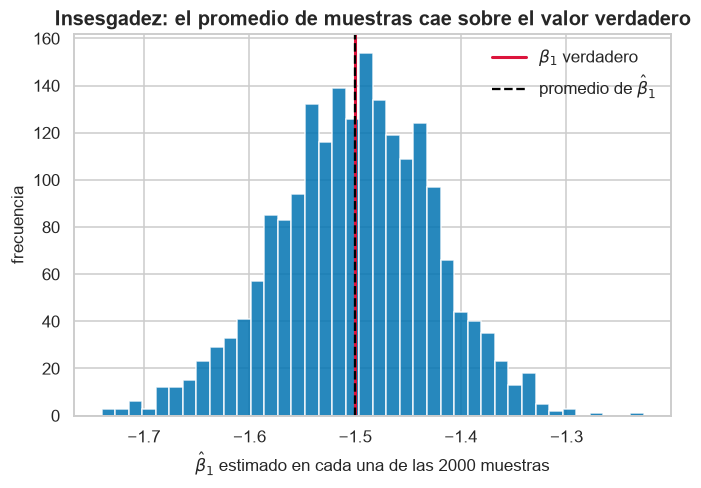

In [7]:
# Ver la insesgadez, no solo leerla: la distribución de beta_1 estimado
# se centra en el valor verdadero, aunque cada muestra individual se aleje.
fig, ax = plt.subplots()
ax.hist(betas_sim[:, 1], bins=40, color=sns.color_palette("colorblind")[0], alpha=0.85)
ax.axvline(beta_verdadero[1], color="crimson", linewidth=2, label=r"$\beta_1$ verdadero")
ax.axvline(betas_sim[:, 1].mean(), color="black", linestyle="--", linewidth=1.5,
           label=r"promedio de $\hat\beta_1$")
ax.set_xlabel(r"$\hat\beta_1$ estimado en cada una de las 2000 muestras")
ax.set_ylabel("frecuencia")
ax.set_title("Insesgadez: el promedio de muestras cae sobre el valor verdadero")
ax.legend()
plt.show()


Repetir el experimento muchas veces con distintas muestras y promediar los
$\hat\beta$ resultantes es la forma más directa de "ver" la insesgadez sin
hacer ninguna cuenta algebraica: el histograma de arriba muestra que cada
muestra individual puede caer lejos del valor verdadero (la campana tiene
ancho), pero la línea negra —el promedio— cae prácticamente encima de la
línea roja —el valor real—.

### ⚠️ Confusión típica

Confundir "insesgado" con "exacto" o "bueno". Insesgado solo dice que el
**promedio** sobre infinitas muestras da el valor correcto. Una muestra
particular puede tener un $\hat\beta$ lejísimos de $\beta$ (es exactamente lo
que muestra el ancho del histograma de arriba): eso es varianza, el tema de
la próxima sección, y es un problema completamente distinto del sesgo.


---

## 5. Varianza, distribución e inferencia sobre $\hat\beta$

📓 celdas 13–16 · 📕 ESL §3.2 · 📘 Bishop §3.1.1

### La idea en criollo

Si la sección anterior mostró que la balanza "no pesa para cualquier lado en
promedio", esta sección pregunta: ¿cuánto **se dispersan** las pesadas
individuales alrededor de ese promedio? Una balanza puede ser insesgada y, al
mismo tiempo, muy poco precisa —cada pesada individual lejos del promedio—, o
insesgada y muy precisa. La varianza mide justamente eso.

> **Dónde se rompe la analogía.** Acá la dispersión no es "ruido del
> instrumento" sino algo que depende directamente de **cómo están distribuidas
> tus variables de entrada** ($\mathbf{X}$): con los mismos datos de $Y$ pero
> un $\mathbf{X}$ distinto, la varianza de $\hat\beta$ cambia. No es una
> propiedad fija del "instrumento de medición", es una propiedad del diseño
> experimental.

### Formalizándolo

**Varianza (celda 13).** Partimos de la misma descomposición de la sección
anterior, $\hat\beta = \beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\epsilon$.
Como $\beta$ es una constante (no aporta varianza), y usando la propiedad
$Var(A\mathbf{b}) = A\,Var(\mathbf{b})\,A^T$ para $A$ matriz constante y
$\mathbf{b}$ vector aleatorio (análoga a la versión escalar
$Var(ab) = a^2 Var(b)$, con la salvedad de que acá $A$ y $A^T$ no son
intercambiables, por eso aparecen los dos):

$$Var(\hat\beta) = Var\big((\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\epsilon\big) = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\,Var(\epsilon)\,\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}$$

Como $Var(\epsilon) = \sigma^2 I$ (supuesto 2 de la sección anterior),
$\sigma^2$ sale como escalar y queda $\mathbf{X}^T I \mathbf{X} = \mathbf{X}^T\mathbf{X}$
en el medio, que se cancela con una de las dos inversas de los costados:

$$Var(\hat\beta) = \sigma^2 (\mathbf{X}^T\mathbf{X})^{-1}(\mathbf{X}^T\mathbf{X})(\mathbf{X}^T\mathbf{X})^{-1} = \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}$$

Esta matriz $(p+1)\times(p+1)$ es la **matriz de varianzas y covarianzas** de
$\hat\beta$: en su diagonal están las varianzas de cada $\hat\beta_j$, y fuera
de la diagonal, las covarianzas entre pares de coeficientes.

**¿Cómo estimamos $\sigma^2$?** (pregunta que la clase se hace y responde en
la misma celda, sin desarrollar por qué):

$$\hat\sigma^2 = \frac{1}{N-p-1}\sum_{i=1}^N (y_i - \hat y_i)^2$$

El numerador es el $RSS$ ya minimizado. El denominador **no** es $N$, que
sería el promedio "ingenuo": es $N - p - 1$, los **grados de libertad**
residuales. La razón es que ya usamos los datos para estimar $p+1$
parámetros ($\hat\beta_0,\dots,\hat\beta_p$); eso "gasta" $p+1$ grados de
libertad de los $N$ que tenías, y dividir por $N$ en lugar de por $N-p-1$
subestimaría sistemáticamente $\sigma^2$ (es el mismo fenómeno, con el mismo
nombre, que la corrección de Bessel al estimar una varianza muestral con
$N-1$ en vez de $N$).

**Distribución de $\hat\beta$ (celda 14).** Como $\epsilon \sim N(0,\sigma^2 I)$
(supuesto 4), y $\hat\beta = \beta + (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\epsilon$
es una **combinación lineal** de las componentes de $\epsilon$ (una matriz
constante multiplicando un vector normal), $\hat\beta$ también es normal —una
combinación lineal de variables normales es normal—. La propiedad general es:
si $\mathbf{b}\sim N(\mu,\Sigma)$ y $A$ es una matriz constante, entonces
$A\mathbf{b}\sim N(A\mu, A\Sigma A^T)$. Acá $A = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$,
y aplicando esa propiedad se recuperan de una sola vez la esperanza y la
varianza que ya habíamos calculado por separado:

$$\hat\beta \sim N\big(\beta,\ \sigma^2(\mathbf{X}^T\mathbf{X})^{-1}\big)$$

**Otros resultados de inferencia (celdas 15–16).** Con $\hat\beta$ normal y
$\hat\sigma^2$ estimado, la clase enumera —sin derivar, y acá tampoco los vamos
a derivar en detalle porque exceden el alcance de esta clase, pero sí a
explicar qué significan y para qué sirven— tres resultados clásicos de
inferencia en regresión lineal:

1. $\hat\sigma^2$ sigue una distribución $\chi^2$ (chi-cuadrado) escalada:
   $\hat\sigma^2 \sim \frac{\sigma^2}{N-p-1}\chi^2_{N-p-1}$. Sirve para
   construir intervalos de confianza para $\sigma^2$ mismo.
2. Para decidir si un coeficiente individual $\beta_j$ es significativamente
   distinto de cero, se usa el **Z-score**:
   $$Z_j = \frac{\hat\beta_j}{\hat\sigma\sqrt{(\mathbf{X}^T\mathbf{X})^{-1}_{jj}}}$$
   El denominador es el **error estándar** de $\hat\beta_j$: la raíz cuadrada
   del elemento $j$-ésimo de la diagonal de $Var(\hat\beta)$, con $\sigma$
   reemplazada por su estimación $\hat\sigma$. Bajo la hipótesis nula
   $\beta_j = 0$, $Z_j$ sigue una distribución $t$ con $N-p-1$ grados de
   libertad (que para $N$ grande se aproxima a una normal estándar).
3. Para comparar **dos modelos anidados** —uno con $p_1+1$ parámetros y otro
   con $p_0+1$ parámetros, $p_0 < p_1$, donde el más chico es un caso
   particular del más grande— se usa el **estadístico $F$**:
   $$F = \frac{(RSS_0 - RSS_1)/(p_1-p_0)}{RSS_1/(N-p_1-1)}$$
   El numerador mide cuánto **mejora** el ajuste (cuánto **baja** el $RSS$)
   por cada parámetro extra que agregás; el denominador normaliza esa mejora
   contra una estimación de $\sigma^2$ del modelo grande. Bajo la hipótesis
   nula de que el modelo chico ya es suficiente, $F$ sigue una distribución
   $F_{p_1-p_0,\,N-p_1-1}$. Si el $F$ observado es mucho mayor que lo que esa
   distribución predice, hay evidencia de que las variables extra sí aportan.

### ¿Por qué nos importa?

Porque el $Z_j$ y el $F$ son, en la práctica, las herramientas que vas a usar
todo el cuatrimestre para decidir "¿esta variable importa o no?" y "¿este
grupo de variables aporta o me lo puedo ahorrar?". El Ejercicio 3 te pide
calcular exactamente el estadístico $F$ del modelo completo contra un modelo
reducido, sobre datos reales, así que esta sección es literalmente la teoría
que necesitás antes de sentarte a hacerlo (la celda de código de abajo
calcula los $Z_j$ del modelo completo — el $F$ del Ejercicio 3 queda para
que lo hagas vos, comparando dos modelos).


In [8]:
# Z-scores del modelo completo sobre prostate.data (reusando X, y de la §2).
N, p = X.shape[0], X.shape[1] - 1  # X incluye la columna de 1s
beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
residuos = y - X @ beta_hat

RSS = residuos @ residuos
sigma2_hat = RSS / (N - p - 1)

cov_beta = sigma2_hat * np.linalg.inv(X.T @ X)   # sigma^2 (X^T X)^-1
errores_estandar = np.sqrt(np.diag(cov_beta))
Z = beta_hat / errores_estandar

nombres = ["intercept"] + pred
for nombre, z in zip(nombres, Z):
    print(f"{nombre:>10s}: Z = {z: .3f}")


 intercept: Z =  0.137
    lcavol: Z =  6.425
   lweight: Z =  3.096
       age: Z = -1.917
      lbph: Z =  1.670
       svi: Z =  3.158
       lcp: Z = -1.180
   gleason: Z =  0.317
     pgg45: Z =  1.021


#### 🏭 Así se hace en la industria

`statsmodels` calcula exactamente esto (y más) con `.summary()`.


In [9]:
import statsmodels.api as sm

modelo_sm = sm.OLS(y, X).fit()  # X ya incluye la columna de 1s
print(modelo_sm.summary().tables[1])


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1816      1.321      0.137      0.891      -2.443       2.806
x1             0.5643      0.088      6.425      0.000       0.390       0.739
x2             0.6220      0.201      3.096      0.003       0.223       1.021
x3            -0.0212      0.011     -1.917      0.058      -0.043       0.001
x4             0.0967      0.058      1.670      0.098      -0.018       0.212
x5             0.7617      0.241      3.158      0.002       0.282       1.241
x6            -0.1061      0.090     -1.180      0.241      -0.285       0.073
x7             0.0492      0.155      0.317      0.752      -0.259       0.358
x8             0.0045      0.004      1.021      0.310      -0.004       0.013


Compará la columna `coef` con `beta_hat` y la columna `t` con los `Z` que
calculamos a mano — statsmodels llama "t" a lo mismo que la clase llama
Z-score (con $N-p-1$ grados de libertad, la $t$ y la $Z$ casi no se
distinguen). Es exactamente lo que hace `statsmodels` cuando le pedís un
`summary()`; el Ejercicio 3 te pide comparar tu propia cuenta con lo que esa
librería devuelve.

### ⚠️ Confusión típica

Usar $N$ en vez de $N-p-1$ al estimar $\sigma^2$, o mirar el $Z$-score de un
coeficiente y decidir "importa" o "no importa" sin pensar en el contexto: un
$Z_j$ chico no dice que la variable $X_j$ no tenga relación con $Y$, dice que
—**dadas las demás variables ya en el modelo**— agregarla no reduce el
residuo de forma que se distinga del ruido. Si sacás otra variable
correlacionada con $X_j$, el $Z_j$ de $X_j$ puede cambiar completamente.


---

## 6. Descenso por gradiente (estocástico)

📓 celdas 17–18 · 📘 Bishop §3.1.3 (*sequential learning*)

### La idea en criollo

Imaginate que estás en la ladera de una montaña con niebla espesa: no ves el
valle, pero sentís hacia dónde baja el terreno bajo tus pies. Una estrategia
razonable para llegar abajo es dar un paso en la dirección de mayor
pendiente descendente, evaluar de nuevo, y repetir. No necesitás un mapa
completo de la montaña (no necesitás resolver ninguna ecuación cerrada):
alcanza con la pendiente **local**, paso a paso.

> **Dónde se rompe la analogía.** En la montaña, un paso demasiado largo en
> niebla te puede hacer caer por un barranco sin darte cuenta; acá, un $\eta$
> (tasa de aprendizaje) demasiado grande hace que la actualización de
> $\beta$ **sobrepase** el mínimo y empiece a oscilar o directamente a
> divergir, en vez de acercarse. Y a diferencia de la montaña, acá sabemos —de
> la §2— que el terreno no tiene barrancos falsos ni mesetas engañosas: $RSS$
> es convexa, así que cualquier camino que baje consistentemente termina en
> el único mínimo global que existe.

### Formalizándolo

La ecuación normal (§2) requiere calcular $\mathbf{X}^T\mathbf{X}$, una
matriz $(p+1)\times(p+1)$ construida a partir de $N$ observaciones. Con $N$
en el orden de millones, esa cuenta —y su inversión o factorización— se vuelve
costosa. El **descenso por gradiente** ofrece una alternativa iterativa que
nunca necesita armar esa matriz.

Partiendo de $RSS = \sum_{i=1}^N (y_i - \hat y_i)^2 = \sum_{i=1}^N (y_i - x_i^T\beta)^2$,
la derivada respecto de $\beta$ (la misma cuenta que en §2, pero escrita como
suma sobre observaciones en vez de en forma matricial) es:

$$\frac{\partial RSS}{\partial \beta} = -2\sum_{i=1}^N (y_i - x_i^T\beta)\,x_i$$

El **gradiente** (promedio de esa derivada sobre las $N$ observaciones) es
$-\frac{1}{N}\frac{\partial RSS}{\partial \beta}$, y la actualización de
descenso por gradiente "completo" (*batch*) sería
$\beta \leftarrow \beta - \eta \cdot \big({-}\frac{1}{N}\frac{\partial RSS}{\partial \beta}\big)$,
es decir, dar un paso de tamaño $\eta$ en la dirección **opuesta** al
gradiente (porque el gradiente apunta hacia donde $RSS$ **crece**, y
queremos bajar).

El problema es que ese gradiente completo **sigue** necesitando recorrer las
$N$ observaciones en cada paso. La solución práctica es el **descenso por
gradiente estocástico** (SGD, *stochastic gradient descent*): en lugar de
usar las $N$ observaciones para calcular un paso, usar **una sola**,
elegida al azar, como aproximación ruidosa del gradiente completo:

1. Inicializar $\beta$ con valores aleatorios.
2. En cada iteración $\tau$:
   - elegir una observación al azar $i$ del conjunto de entrenamiento;
   - calcular su error: $e_i = y_i - \hat y_i = y_i - x_i^T\beta$;
   - actualizar $\beta^{(\tau+1)} = \beta^{(\tau)} + \eta\, e_i\, x_i$.

Esa actualización es, literalmente, un paso en la dirección de $x_i$ escalado
por el error $e_i$ y la tasa $\eta$: si el modelo subestima $y_i$ ($e_i>0$),
empuja $\beta$ para que la predicción en esa observación suba; si lo
sobreestima, la empuja para abajo. **¿Por qué es un gradiente?** Porque esa
actualización es exactamente $\beta \leftarrow \beta + \eta\, e_i x_i$, que es
el mismo paso $-\eta \cdot (\text{gradiente})$ de arriba pero usando **una
sola observación** $i$ en lugar del promedio sobre las $N$: es una versión
ruidosa, pero no sesgada en promedio, del gradiente completo.

### ¿Por qué nos importa?

Porque SGD (y sus variantes por *batches*, que el Ejercicio 4 te pide pensar
sin implementar) es el método de optimización que sostiene prácticamente
todo el aprendizaje automático moderno, mucho más allá de la regresión
lineal: redes neuronales enteras se entrenan con variantes de esta misma
idea. Acá lo ves en el caso más simple posible, uno donde además **existe**
una solución cerrada con la que comparar, lo que te da una forma directa de
chequear si tu implementación converge al lugar correcto (exactamente lo que
pide el Ejercicio 4: graficar la evolución de cada $\beta_j$ contra el valor
obtenido por la ecuación normal).


In [10]:
rng_sgd = np.random.default_rng(0)

N_sgd, p1_sgd = 500, 3  # p1 = p + 1, incluyendo el intercepto
X_sgd = np.column_stack([np.ones(N_sgd), rng_sgd.normal(size=(N_sgd, p1_sgd - 1))])
beta_verdadero_sgd = np.array([1.0, 2.0, -1.0])
y_sgd = X_sgd @ beta_verdadero_sgd + rng_sgd.normal(scale=0.5, size=N_sgd)

beta_cerrada, *_ = np.linalg.lstsq(X_sgd, y_sgd, rcond=None)  # para comparar

beta_iter = rng_sgd.normal(size=p1_sgd)  # inicialización aleatoria, no en cero
eta = 0.01
historia = [beta_iter.copy()]
for _ in range(300):
    i = rng_sgd.integers(N_sgd)
    e_i = y_sgd[i] - X_sgd[i] @ beta_iter
    beta_iter = beta_iter + eta * e_i * X_sgd[i]
    historia.append(beta_iter.copy())

historia = np.array(historia)
print("beta (SGD, 300 pasos):   ", beta_iter.round(4))
print("beta (ecuación normal):  ", beta_cerrada.round(4))


beta (SGD, 300 pasos):    [ 0.9611  1.89   -1.0971]
beta (ecuación normal):   [ 1.0267  2.0181 -1.0233]


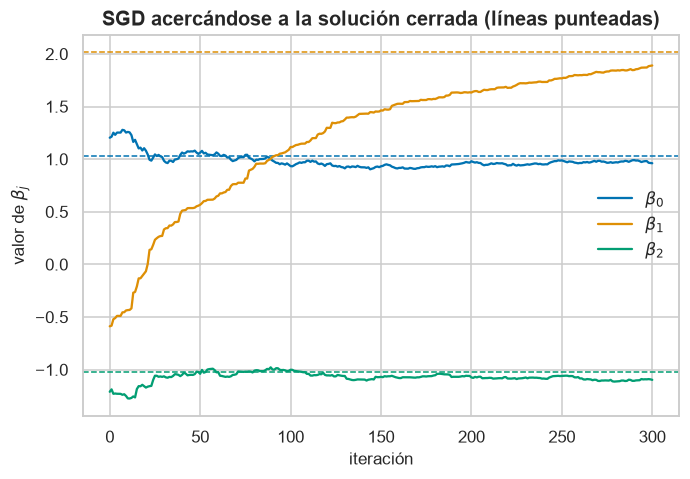

In [11]:
# Ilustración de convergencia: cada beta_j se acerca al valor de la ecuación
# normal a medida que avanzan los pasos de SGD. No es el Ejercicio 4 (que usa
# prostate.data, eta=0.001 y 10000 iteraciones con predictores escalados) —
# es un ejemplo más chico, solo para ver la mecánica.
fig, ax = plt.subplots()
paleta = sns.color_palette("colorblind")
for j in range(p1_sgd):
    ax.plot(historia[:, j], color=paleta[j], label=fr"$\beta_{j}$")
    ax.axhline(beta_cerrada[j], color=paleta[j], linestyle="--", linewidth=1)
ax.set_xlabel("iteración")
ax.set_ylabel(r"valor de $\beta_j$")
ax.set_title("SGD acercándose a la solución cerrada (líneas punteadas)")
ax.legend()
plt.show()


Cada curva sólida es un $\beta_j$ actualizándose paso a paso; la línea
punteada del mismo color es el valor que da la ecuación normal para ese mismo
$\beta_j$. Con pocos cientos de pasos ya se nota el acercamiento, aunque
sigue oscilando (es la naturaleza "ruidosa" de usar una sola observación por
paso). El Ejercicio 4 pide una implementación completa, con $\eta$, número de
iteraciones y datos específicos, y comparar contra la solución cerrada — no
es lo mismo que este ejemplo ilustrativo.

### ⚠️ Confusión típica

Pensar que $\eta$ es un detalle menor. Un $\eta$ demasiado chico hace que el
algoritmo converja correctamente pero muy lento (necesitás muchísimas
iteraciones); uno demasiado grande hace que la actualización sobrepase el
mínimo en cada paso y el algoritmo oscile sin asentarse, o directamente
diverja. No hay un $\eta$ "universal": depende de la escala de los datos —de
ahí la recomendación de la clase, y del propio Ejercicio 4, de **escalar los
predictores** antes de entrenar.

Segunda confusión: inicializar $\beta$ en cero "para no arrancar de
cualquier lado". Con $RSS$ convexa (§2), el punto de partida no cambia **a
dónde** converge el algoritmo, pero sí puede cambiar cuánto tarda o, en
modelos no convexos que vas a ver más adelante en la materia, directamente a
qué mínimo local llega. Inicializar todos los $\beta_j$ en el mismo valor
(cero incluido) puede ser problemático en otros modelos donde esa simetría
hace que distintos parámetros aprendan siempre lo mismo; en regresión lineal
pura eso no ocurre, pero la costumbre de inicializar con ruido aleatorio
—como pide la clase, con $N(0,1)$— es la que se generaliza bien al resto de
la materia.


---

## 🧵 El hilo conductor

La clase anterior (`1_intro_teoria_decision.ipynb`) dejó planteado un problema
general: bajo pérdida cuadrática, el predictor óptimo es
$f^*(X) = E(Y\mid X)$, la esperanza condicional de $Y$ dado $X$ (ESL §2.4).
El problema es que, en general, esa función es completamente desconocida:
podría ser cualquier cosa, y estimarla sin ninguna restricción requeriría
—por la maldición de la dimensionalidad, otro tema de esa clase anterior—
una cantidad de datos que casi nunca tenés.

Esta clase toma ese problema abstracto y lo hace concreto: apuesta a que
$E(Y\mid X)$ se puede aproximar bien con un **hiperplano**,
$f(X) = X^T\beta$. Esa apuesta simplifica brutalmente el problema de
estimación: en vez de "encontrar una función arbitraria", el problema se
reduce a "encontrar $p+1$ números", los coeficientes $\beta$. Y esa
simplificación es tan fuerte que —cuando además la pérdida es cuadrática—
el problema tiene **solución cerrada**: la ecuación normal. La geometría de
la proyección ortogonal (§3) es la forma más económica de entender por qué
esa fórmula particular resuelve el problema, y las secciones de estadística
(§4–§5) son lo que hace falta agregar para poder decir algo sobre **qué tan
bien** estimaste esos $\beta$, no solo cuáles son.

La última pieza (§6) mira hacia adelante: la ecuación normal es elegante pero
no escala a datasets gigantes. El descenso por gradiente estocástico resuelve
el mismo problema con una herramienta completamente distinta —iterativa,
aproximada, sin álgebra matricial pesada—, y es la herramienta que vas a ver
una y otra vez el resto de la cursada, en modelos donde la solución cerrada
directamente no existe. La clase que sigue (máxima verosimilitud y SVD, ver
`3_regresion_lineal_maxima_verosimilitud_svd.ipynb`) retoma exactamente esta
misma ecuación normal desde otro ángulo —máxima verosimilitud en vez de
mínimos cuadrados— y muestra que da lo mismo, además de resolver el problema
del rango incompleto que quedó abierto en la §3 de esta clase.

## ✅ Autoevaluación

**1.** ¿Por qué se dice que la regresión lineal es "lineal en los
parámetros" y no necesariamente en las variables? Dar un ejemplo de un
modelo con un predictor no lineal en $X$ que siga siendo regresión lineal.

<details><summary>Respuesta</summary>

Porque la condición que define al modelo es que $f(X) = \beta_0 + \sum_j
X_j\beta_j$ sea una combinación **lineal** de los coeficientes $\beta_j$. Las
$X_j$ pueden ser cualquier transformación de las variables originales —por
ejemplo, $f(X) = \beta_0 + \beta_1 X_1 + \beta_2 X_1^2$ es "regresión
lineal" (lineal en $\beta_0,\beta_1,\beta_2$) aunque como función de $X_1$
dibuje una parábola.

</details>

**2.** ¿Qué significa, en palabras, que $\mathbf{X}^T\mathbf{X}$ tenga rango
columna incompleto? Dar un ejemplo concreto de cómo se puede llegar a esa
situación al construir $\mathbf{X}$.

<details><summary>Respuesta</summary>

Significa que alguna columna de $\mathbf{X}$ se puede escribir como
combinación lineal de las demás: hay redundancia entre predictores. Ejemplo
clásico: codificar una variable categórica con $k$ categorías usando $k$
variables dummy (una por categoría) **y además** dejar la columna de 1s del
intercepto. La suma de las $k$ dummies es, para cada fila, siempre igual a 1
—la misma columna que el intercepto—, así que esa columna es combinación
lineal de las otras. En ese caso $\mathbf{X}^T\mathbf{X}$ no es invertible.

</details>

**3.** Un punto crítico de $RSS(\beta)$ (donde la derivada se anula) —
¿alcanza para asegurar que ahí está el mínimo? ¿Qué hace falta chequear
además?

<details><summary>Respuesta</summary>

No alcanza: derivada primera igual a cero solo prueba que hay un punto
crítico, que podría ser un mínimo, un máximo o una silla. Hace falta mirar
la segunda derivada (la Hessiana), $2\mathbf{X}^T\mathbf{X}$. Esa matriz es
semidefinida positiva siempre, y **definida** positiva (lo que garantiza un
mínimo estricto) si y solo si $\mathbf{X}$ tiene rango columna completo.

</details>

**4.** Geométricamente, ¿qué relación hay entre el vector de residuos
$\mathbf{y} - \hat{\mathbf{y}}$ y el subespacio generado por las columnas de
$\mathbf{X}$?

<details><summary>Respuesta</summary>

Son ortogonales: el vector de residuos es perpendicular a cada columna de
$\mathbf{X}$ (y por lo tanto a todo el subespacio que generan). Esto sale
directo de la ecuación normal, $\mathbf{X}^T(\mathbf{y}-\mathbf{X}\hat\beta)=0$,
y es la razón por la que $\hat{\mathbf{y}}$ es la proyección ortogonal de
$\mathbf{y}$ sobre ese subespacio.

</details>

**5.** ¿Por qué al estimar $\sigma^2$ se divide por $N-p-1$ y no por $N$?

<details><summary>Respuesta</summary>

Porque ya se usaron los datos para estimar $p+1$ parámetros
($\hat\beta_0,\dots,\hat\beta_p$), y eso "consume" $p+1$ grados de libertad.
Dividir por $N$ subestimaría sistemáticamente $\sigma^2$, porque el $RSS$
calculado con $\hat\beta$ (el que minimiza el error en la muestra) es, en
promedio, más chico que el que se obtendría con el $\beta$ verdadero. Es el
mismo fenómeno que motiva dividir por $N-1$ al estimar una varianza muestral
simple.

</details>

**6.** Tenés $N=50$ observaciones y $p=80$ predictores. ¿Qué pasa con
$\hat\beta$?

<details><summary>Respuesta</summary>

$\mathbf{X}$ es $50\times 81$: no puede tener rango columna completo, porque
el rango está acotado por el mínimo entre filas y columnas ($\leq 50$).
Entonces $\mathbf{X}^T\mathbf{X}$ es singular y no hay un único $\hat\beta$:
hay un subespacio entero de soluciones que ajustan los 50 puntos
**exactamente** ($RSS=0$). El modelo no aprendió ninguna estructura,
memorizó los datos. Este escenario es justamente el que motiva selección de
variables y regularización (ESL cap. 3, a partir de §3.3).

</details>

**7.** En descenso por gradiente estocástico, ¿qué pasa si elegís una tasa
de aprendizaje $\eta$ mucho más grande que la que hace falta?

<details><summary>Respuesta</summary>

Cada actualización $\beta \leftarrow \beta + \eta\, e_i x_i$ da un paso
demasiado largo en la dirección del gradiente estimado, y en vez de
acercarse gradualmente al mínimo, lo sobrepasa. El resultado típico es que
$\beta$ empieza a oscilar de un lado a otro del mínimo sin asentarse, o —si
$\eta$ es extremo— que la magnitud de $\beta$ crezca sin control (diverja) en
vez de converger.

</details>

**8.** ¿Por qué el descenso por gradiente estocástico usa una sola
observación por paso en lugar de las $N$ enteras, si eso hace que cada paso
sea más "ruidoso"?

<details><summary>Respuesta</summary>

Porque calcular el gradiente completo requiere recorrer las $N$
observaciones en cada iteración, algo costoso cuando $N$ es muy grande. Usar
una sola observación (elegida al azar) da una estimación ruidosa pero
correcta en promedio del gradiente completo, y permite dar muchísimos más
pasos por unidad de tiempo de cómputo. El ruido adicional se compensa con la
cantidad de pasos que se pueden dar.

</details>

**9.** ¿Qué mide el estadístico $F$ y cuándo tiene sentido usarlo en lugar
de mirar los $Z$-scores individuales?

<details><summary>Respuesta</summary>

El $F$ compara dos modelos anidados (uno con más parámetros que el otro,
donde el chico es un caso particular del grande): mide cuánto **baja** el
$RSS$ al agregar el grupo de variables extra, normalizado por una estimación
de $\sigma^2$ del modelo grande. Tiene sentido usarlo en vez de $Z$-scores
individuales cuando querés testear varias variables **en conjunto** (por
ejemplo, todas las categorías de una variable categórica codificada con
varias dummies), porque cada $Z_j$ por separado puede no ser significativo
aunque el grupo, en conjunto, sí aporte.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Mínimo cuadrático vs. mínimo absoluto de un conjunto de valores

- **De qué va realmente:** es el caso más chico posible de "ajustar un
  modelo": ni siquiera hay variables predictoras, solo estimar una
  **constante** $x$ que resuma un montón de valores. La gracia es comparar
  qué constante conviene según qué error uses, y por qué cambia.
- **Por dónde arrancar:** para la parte cuadrática, escribí
  $g(x) = \sum_i (x_i - x)^2$, derivala respecto de $x$ e igualá a cero — es
  exactamente el mismo procedimiento de la §2 pero en una sola variable,
  sin matrices de por medio. Para la parte con error absoluto, la derivada
  de $|x_i - x|$ no está definida en $x_i = x$; pensá el problema por tramos
  en lugar de derivar directamente.
- **Con qué chequear:** el resultado del error cuadrático te tiene que dar
  un promedio muy conocido. El del error absoluto te tiene que dar otra
  medida de tendencia central, distinta de esa.
- **⚠️ Dónde te vas a trabar:** al querer aplicarle el mismo método de "derivar
  e igualar a cero" al caso del error absoluto. Ahí no funciona igual —la
  función no es diferenciable en todos lados— y hace falta razonar el
  problema de otra manera.

### Ejercicio 2 — La ecuación normal a mano, con una sola variable

- **De qué va realmente:** repetir, con $p=1$ y sin ninguna notación
  matricial, exactamente la misma cuenta que la §2 hizo en forma matricial.
  La gracia es que te tienen que salir las **mismas** dos fórmulas por los
  dos caminos, y que veas en carne propia por qué la notación matricial se
  vuelve indispensable apenas $p$ crece.
- **Por dónde arrancar:** escribí $RSS(\beta_0,\beta_1) = \sum_i(y_i -
  \beta_0 - \beta_1 x_i)^2$ y derivá **parcialmente** respecto de cada uno de
  los dos parámetros por separado. Te quedan dos ecuaciones con dos
  incógnitas: despejá $\beta_0$ de la primera y reemplazalo en la segunda.
- **Con qué chequear:** te tiene que quedar $\hat\beta_1$ como un cociente
  entre algo que se parece a una covarianza (entre $x$ e $y$) y algo que se
  parece a una varianza (de $x$). Si te dio eso, vas bien. Verificación
  numérica: generá datos con `numpy`, aplicá tu fórmula a mano y comparala
  contra `np.polyfit(x, y, 1)`.
- **⚠️ Dónde te vas a trabar:** en la parte de estandarizar. Escribí
  explícitamente qué valen $\bar x$ y $\bar y$ **después** de estandarizar
  (¿cuánto valen esos promedios una vez estandarizados los datos?) antes de
  reemplazar en la fórmula; buena parte de los términos se te van a caer
  solos si lo hacés en ese orden.

### Ejercicio 3 — Prostate Cancer: replicar tablas 3.1/3.2 y el estadístico F

- **De qué va realmente:** confirmar con datos reales que la cuenta teórica
  de las §2, §4 y §5 (ecuación normal, $Z$-scores, estadístico $F$) da
  exactamente los mismos números que reporta ESL, calculados por tres
  caminos distintos (a mano con `numpy`, con `statsmodels`, y comparados
  contra el libro).
- **Por dónde arrancar:** primero conseguí el dataset y separá entrenamiento
  de evaluación como lo hace el libro (la columna `train` de
  `prostate.data`, que ya usamos en las secciones §2, §3 y §5 sin partir).
  Antes de tocar código, mirá qué columnas tiene la Tabla 3.1 (correlaciones)
  y la 3.2 (coeficientes y $Z$-scores) para saber qué tenés que producir.
- **Con qué chequear:** los números de tu ajuste tienen que coincidir (salvo
  redondeo) con los que aparecen impresos en las Tablas 3.1 y 3.2 de ESL —es
  la referencia con número que sí podés citar directamente. Si tu `numpy` a
  mano y tu `statsmodels` no coinciden entre sí, hay un error antes de
  comparar contra el libro.
- **⚠️ Dónde te vas a trabar:** en el estadístico $F$ del modelo reducido.
  Tenés que ajustar **dos** modelos (completo y reducido, sacando las
  variables indicadas) y usar el $RSS$ de cada uno con la fórmula de la §5 —
  es un error común calcular el $F$ con el $RSS$ de un solo modelo.

### Ejercicio 4 — Prostate Cancer: descenso por gradiente estocástico

- **De qué va realmente:** implementar el algoritmo de la §6 completo (no
  el fragmento ilustrativo de esta explicación, que usa datos sintéticos y
  pocas iteraciones) sobre datos reales, y verificar con tus propios ojos
  que converge al mismo $\hat\beta$ que la ecuación normal ya calculada en
  el Ejercicio 3.
- **Por dónde arrancar:** antes de escribir el loop de actualización,
  **escalá** los predictores (la clase y el enunciado insisten en esto por
  algo: mirá la ⚠️ de la §6 para entender por qué importa tanto). Después sí,
  el loop es exactamente el pseudocódigo de la §6, con $\eta=0.001$ y 10000
  iteraciones.
- **Con qué chequear:** graficando cada $\beta_j$ contra la cantidad de
  iteraciones (como el gráfico de la §6, pero con datos reales y muchas más
  iteraciones), la curva se tiene que ir acercando y estabilizando cerca del
  valor que obtuviste con la ecuación normal (o con `statsmodels`) en el
  Ejercicio 3. Si no converge ahí, sospechá primero del escalado y después
  de $\eta$.
- **⚠️ Dónde te vas a trabar:** al comparar visualmente contra la ecuación
  normal si no escalaste los predictores de la misma forma en los dos
  ejercicios: los $\beta_j$ de un modelo con predictores escalados **no son
  directamente comparables** con los de un modelo sin escalar, así que
  necesitás dejar ambos en la misma escala antes de graficarlos juntos.

### Ejercicio 5 — Código fuente de LinearRegression en scikit-learn

- **De qué va realmente:** conectar la teoría de la §2 (por qué `lstsq` es
  mejor que `inv`) con la implementación real que usa una librería que
  probablemente ya usaste sin mirar adentro (la misma que usamos en la §2
  para comparar contra la SVD a mano).
- **Por dónde arrancar:** empezá por la sección "Notes" de la documentación
  oficial, no por el código fuente directamente: ahí suele estar explicado
  en palabras qué método numérico usa antes de que lo veas en la
  implementación.
- **Con qué chequear:** tenés que poder nombrar, con precisión, qué
  descomposición matricial usa `sklearn` internamente (la misma que se
  menciona en el bloque "En código" de la §2), y contrastarla explícitamente
  con la fórmula $\hat\beta=(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$
  que dedujimos a mano.
- **⚠️ Dónde te vas a trabar:** el código de `sklearn` maneja casos generales
  (datos dispersos, múltiples salidas, distintos *solvers* según la forma de
  los datos) que agregan ramas de código no relacionadas con la cuenta
  central. No hace falta entender cada rama: identificá primero el camino
  que se toma en el caso simple (una sola variable de salida, datos densos).

### Ejercicio 6 — Solvers de Ridge en scikit-learn

- **De qué va realmente:** es un adelanto de la próxima clase (regularización,
  ESL §3.4), pero se puede empezar a leer ya con lo que sabés de esta: Ridge
  agrega un término a la misma $RSS(\beta)$ de la §2, y por eso también tiene
  varios *solvers* posibles, análogos a los tres que viste en el bloque "En
  código" de la §2 (`inv`, `solve`, `lstsq`).
- **Por dónde arrancar:** leé la documentación del parámetro `solver` de
  `Ridge` y anotá, para cada opción, si resuelve el problema con una fórmula
  cerrada (como la ecuación normal de esta clase) o de forma iterativa (como
  el descenso por gradiente de la §6).
- **Con qué chequear:** tenés que poder ubicar, de la lista de *solvers*, al
  menos uno que sea "el equivalente Ridge" de la ecuación normal de esta
  clase, y al menos uno que sea "el equivalente Ridge" del descenso por
  gradiente.
- **⚠️ Dónde te vas a trabar:** algunos *solvers* de `Ridge` no son ni la
  ecuación normal directa ni descenso por gradiente estocástico puro, sino
  variantes intermedias (por ejemplo, basadas en descomposiciones
  específicas para problemas regularizados). No hace falta resolver a fondo
  ese caso para este ejercicio — la clase dice explícitamente "volveremos
  sobre este ejercicio" — alcanza con identificar la diferencia gruesa entre
  "cerrado" e "iterativo".
